In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/patelris/anime-and-manga-dataset-2026/anime_dataset.csv
/kaggle/input/datasets/patelris/anime-and-manga-dataset-2026/manga_dataset.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# =========================
# LOAD DATA
# =========================
anime = pd.read_csv("/kaggle/input/datasets/patelris/anime-and-manga-dataset-2026/anime_dataset.csv")

# =========================
# CLEANING
# =========================
anime = anime.dropna(subset=["score"])
anime["episodes"] = anime["episodes"].fillna(0)
anime["members"] = anime["members"].fillna(0)
anime["favorites"] = anime["favorites"].fillna(0)

# Convert duration to minutes
def parse_duration(x):
    try:
        return int(x.split()[0])
    except:
        return 0

anime["duration_min"] = anime["duration"].apply(parse_duration)

# =========================
# FEATURE ENGINEERING
# =========================
anime["engagement_ratio"] = anime["favorites"] / (anime["members"] + 1)
anime["score_weighted"] = anime["score"] * np.log1p(anime["scored_by"])

# Split genres
anime["genres"] = anime["genres"].fillna("")
anime["genre_list"] = anime["genres"].apply(lambda x: x.split("|"))

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(anime["genre_list"]),
    columns=mlb.classes_,
    index=anime.index
)

anime = pd.concat([anime, genre_encoded], axis=1)

# =========================
# MODEL DATA
# =========================
features = ["episodes", "members", "favorites", "duration_min", "engagement_ratio"] + list(mlb.classes_)

X = anime[features]
y = anime["score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================
# MODEL: XGBOOST
# =========================
model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05)
model.fit(X_train, y_train)

# =========================
# EVALUATION
# =========================
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"RMSE: {rmse:.4f}")

# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop Features:")
print(importance.sort_values(ascending=False).head(10))

RMSE: 0.5172

Top Features:
favorites           0.430015
Avant Garde         0.093792
Hentai              0.083256
Ecchi               0.040436
Horror              0.039090
engagement_ratio    0.027440
Adventure           0.025840
episodes            0.020569
Erotica             0.020205
                    0.018623
dtype: float32


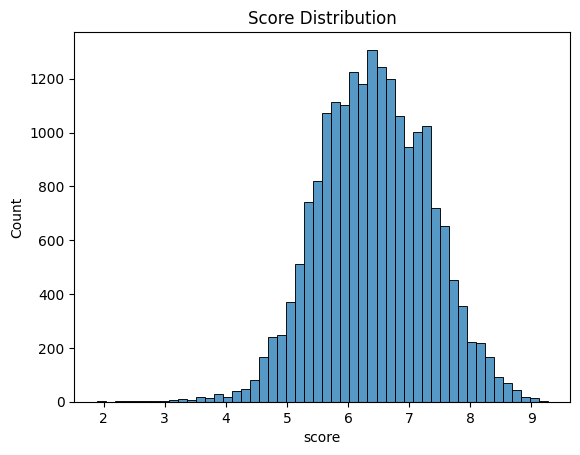

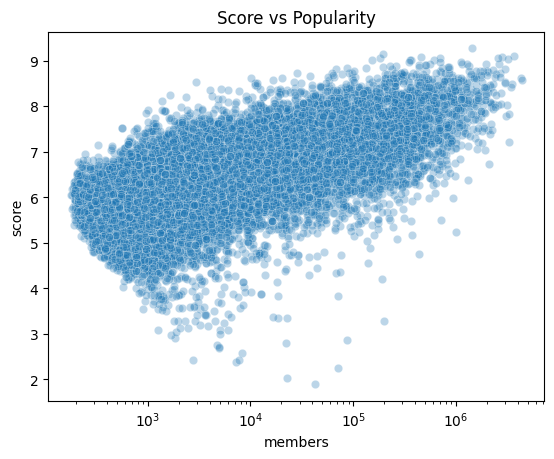

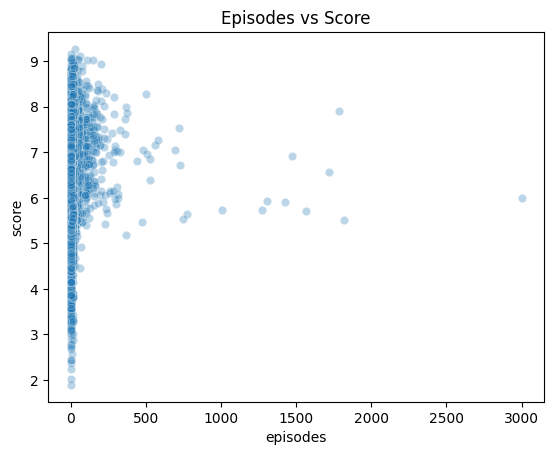

In [3]:

import seaborn as sns
import matplotlib.pyplot as plt


# Score distribution
plt.figure()
sns.histplot(anime["score"].dropna(), bins=50)
plt.title("Score Distribution")
plt.show()

# Score vs Popularity
plt.figure()
sns.scatterplot(x="members", y="score", data=anime, alpha=0.3)
plt.xscale("log")
plt.title("Score vs Popularity")
plt.show()

# Episodes vs Score
plt.figure()
sns.scatterplot(x="episodes", y="score", data=anime, alpha=0.3)
plt.title("Episodes vs Score")
plt.show()

In [4]:

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer


# Fill missing
anime["genres"] = anime["genres"].fillna("")
anime["synopsis"] = anime["synopsis"].fillna("")

# Combine text
anime["content"] = anime["genres"] + " " + anime["synopsis"]

# TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(anime["content"])

# Similarity
cos_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Index mapping
indices = pd.Series(anime.index, index=anime["title"]).drop_duplicates()

def recommend(title, top_n=5):
    idx = indices.get(title)
    if idx is None:
        return "Anime not found"

    sim_scores = list(enumerate(cos_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    anime_indices = [i[0] for i in sim_scores]
    return anime["title"].iloc[anime_indices]

# Example
print(recommend("Cowboy Bebop"))

1                          Cowboy Bebop: Tengoku no Tobira
16133                            Kandagawa Jet Girls Recap
16400    Kandagawa Jet Girls: Koko kara Hajimaru Tokyo ...
15876                                  Kandagawa Jet Girls
27399                          Virgin Punk: Clockwork Girl
Name: title, dtype: object
